# MIL between largest cancer types and healthy

Include healthy in objective as it is shared across plates and cancer types classification could cheat using plate effect.

In [21]:
import importlib 
import util, models, training, eval

importlib.reload(util)
importlib.reload(models)
importlib.reload(training)
importlib.reload(eval)

<module 'eval' from '/home/unix/hschluet/projects/pt-pbmc/eval.py'>

In [1]:
from data import PlateDataset
from util import torch_random_choice
from models import GatedAttentionMulti, GatedAttention
from training import train_model

import torch
import numpy as np
import pandas as pd
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
import torchvision.transforms as T 
import seaborn as sns
import umap


device = 'cuda:0'

In [9]:
data = PlateDataset([3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

  0%|                                                                                                                                                                                          | 0/10 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:03<00:00,  3.01it/s]


In [14]:
use_groups = ['healthy', 'H&N cancer', 'CNS-Meningioma', 'Chordoma/Chondrosarcoma'] 
cdf = data.info[data.info['group'].isin(use_groups)].groupby(['patient', 'time'])['cell'].count().reset_index()
cdf = cdf[(cdf['cell'] > 100)]

p01s = cdf[(cdf['time'] == 1) | (cdf['time'] == 0)]['patient'].unique()
p01s

array(['H06', 'H07', 'H09', 'H10', 'H16', 'H19', 'H20', 'H22', 'H23',
       'H26', 'H29', 'H30', 'H31', 'H32', 'H33', 'H36', 'H37', 'H39',
       'H40', 'H43', 'H47', 'H49', 'P102', 'P105', 'P106', 'P107', 'P110',
       'P112', 'P114', 'P115', 'P118', 'P119', 'P120', 'P125', 'P126',
       'P128', 'P129', 'P130', 'P131', 'P134', 'P135', 'P137', 'P138',
       'P14', 'P142', 'P143', 'P144', 'P145', 'P147', 'P148', 'P149',
       'P152', 'P154', 'P155', 'P160', 'P161', 'P162', 'P163', 'P165',
       'P166', 'P18', 'P21', 'P23', 'P24', 'P25', 'P27', 'P33', 'P37',
       'P38', 'P42', 'P43', 'P44', 'P48', 'P55', 'P59', 'P62', 'P63',
       'P67', 'P69', 'P70', 'P72', 'P76', 'P78', 'P79', 'P83', 'P86',
       'P90', 'P92', 'P94', 'P98', 'P99'], dtype=object)

In [16]:
use_plates = np.array([3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
use_groups = ['healthy', 'H&N cancer', 'CNS-Meningioma', 'Chordoma/Chondrosarcoma'] 
short_groups = {'healthy' : 'H', 'H&N cancer' : 'H&N', 'CNS-Meningioma' : 'M', 'Chordoma/Chondrosarcoma' : 'C/C', 'CNS-Glioma' : 'G'}  
group_map = {'healthy' : 0, 'H&N cancer' : 1, 'CNS-Meningioma' : 2, 'Chordoma/Chondrosarcoma' : 3, 'CNS-Glioma' : 4} 

def group_bagloader(bag_size=50, use_patients=p01s, use_times=[0, 1], use_plates=use_plates, device=device, transform=T.CenterCrop(28)):
  use_idx = torch.argwhere(torch.from_numpy((data.info['plate'].isin(use_plates) & data.info['time'].isin(use_times)).values)).flatten()
  use_data = transform(data.imgs[use_idx].to(device))
  
  plate_pats = np.concatenate(data.info.groupby(['plate'])['patient'].unique().loc[use_plates].values)
  use_patients = use_patients[np.isin(use_patients, plate_pats)]
  
  pat_groups = data.info.groupby(['group'])['patient'].unique().map(lambda x: x[np.isin(x, use_patients)])
  pat_lut = {}
  for pat in use_patients:
    pat_lut[pat] = torch.argwhere(torch.from_numpy((data.info.loc[use_idx]['patient'] == pat).values)).flatten().to(device)

  while True:
    label = np.random.choice(use_groups)
    pat = np.random.choice(pat_groups[label])
    xs = use_data[torch_random_choice(pat_lut[pat], size=bag_size)]
    label = group_map[label]
    yield xs.float(), torch.tensor(label).to(device)


def test_group_bagloader(bag_size=50, reps=5, use_patients=p01s, use_times=[0, 1], use_plates=use_plates, device=device, transform=T.CenterCrop(28)):
  use_idx = torch.argwhere(torch.from_numpy((data.info['plate'].isin(use_plates) & data.info['time'].isin(use_times)).values)).flatten()
  use_data = transform(data.imgs[use_idx].to(device))
  
  pat_groups = data.info.groupby(['patient'])['group'].max()
  pat_plates = data.info.groupby(['patient'])['plate'].unique()
  for pat in use_patients:
    if not np.isin(pat_plates[pat], use_plates).any():
      continue
    pat_idx = torch.argwhere(torch.from_numpy((data.info.loc[use_idx]['patient'] == pat).values)).flatten().to(device)
    for _ in range(reps):
      xs = use_data[torch_random_choice(pat_idx, size=bag_size)]
      label = pat_groups[pat]
      yield xs.float(), torch.tensor(group_map[label]).to(device), pat, label

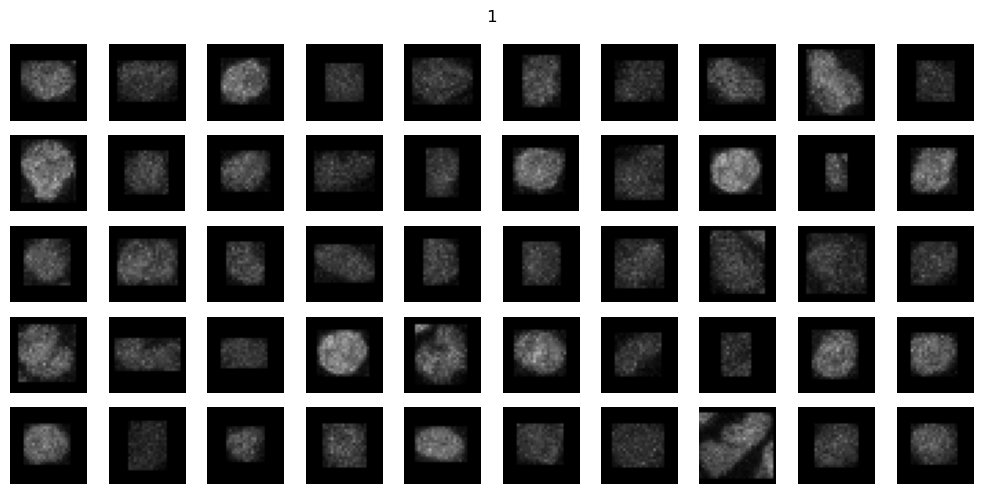

In [17]:
bag, lab = next(group_bagloader())
fig, axs = plt.subplots(5, 10, figsize=(10, 5))
for im, ax in zip(bag, axs.flatten()):
  ax.imshow(im.squeeze().cpu(), cmap='gray', vmax=1, vmin=0)
  ax.axis('off')
fig.suptitle(lab.item())
fig.tight_layout()
fig.show()

In [18]:
def eval_model(name, loader, branches=1, classes=1):
    if classes > 1:
      model = GatedAttentionMulti(classes=classes, branches=branches)
    else:
      model = GatedAttention(branches=branches)
    model = model.to(device)
    model.load_state_dict(torch.load(f'/ewsc/hschluet/models/pbmc5/revision_rerun/{name}_model.pt', weights_only=True, map_location=device))
    model.eval()

    np.random.seed(1232412)
    torch.manual_seed(124514)
    torch.cuda.manual_seed_all(13513)

    bag_labs = []
    bag_pred = []
    bag_ids = []
    bag_attn = []
    bag_rattn = []
    bag_zs = []
    bag_pats = []
    bag_groups = []
    bags = []
    for i, (bag, lab, pat, group) in enumerate(loader):
        with torch.no_grad():
            _, pred, attn, rattn, z = model(bag.to(device))
        bag_ids.extend([i] * 50)
        bag_pats.extend([pat] * 50)
        bag_groups.extend([group] * 50)
        bag_labs.extend([lab.item()] * 50)
        bag_pred.extend([pred.cpu().item()] * 50)
        if branches == 1:
            bag_attn.extend(attn.cpu().squeeze().numpy())
            bag_rattn.extend(rattn.cpu().squeeze().numpy())
        else:
            bag_attn.extend(attn.T.cpu().squeeze().numpy())
            bag_rattn.extend(rattn.T.cpu().squeeze().numpy())
        bag_zs.extend(z.cpu().numpy())
        bags.extend(bag.cpu().numpy())

    df = pd.DataFrame()
    df['lab'] = bag_labs
    df['pred'] = bag_pred
    df['i'] = bag_ids
    df['pat'] = bag_pats
    df['group'] = bag_groups
    if branches == 1:
        df['attention'] = bag_attn
        df['raw attention'] = bag_rattn
    else:
        df[[f'attention {i}' for i in range(branches)]] = bag_attn
        df[[f'raw attention {i}' for i in range(branches)]] = bag_rattn
    return df, bag_zs, bags

## Big model

iter: 499999; train loss: 0.35169721; train error: 0.00000000: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 500000/500000 [37:10<00:00, 224.21it/s]


/ewsc/hschluet/models/pbmc5/rerun//3_12_t01_healthy_groups_mil_model.pt


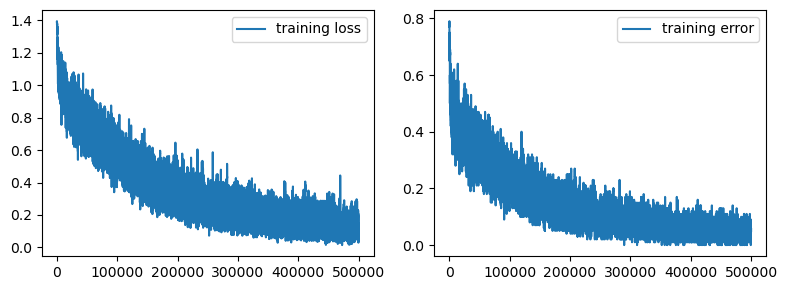

In [19]:
name = '3_12_t01_healthy_groups_mil'
train_loader = group_bagloader()
model = GatedAttentionMulti(classes=len(use_groups), branches=5)
df = train_model(model, bag_loader=train_loader, num_iter=500_000, lr=0.0001, device=device, fname=name, plot=False, 
                 save_model=True, seed=12341, 
                 transform=T.Compose([T.ColorJitter(brightness=0.2, contrast=0.2), T.RandomHorizontalFlip(), T.RandomVerticalFlip()]))

w = 100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.plot(np.convolve(df['train loss'], np.ones(w), 'valid') / w, label='training loss')
ax2.plot(np.convolve(df['train error'], np.ones(w), 'valid') / w, label='training error')
ax1.legend()
ax2.legend()
fig.tight_layout()
fig.show()

## Leave out one plate

iter: 499999; train loss: 0.00003457; train error: 0.00000000: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 500000/500000 [34:10<00:00, 243.88it/s]


/ewsc/hschluet/models/pbmc5/rerun//3_12_t01_healthy_groups_without_plate_3_mil_model.pt


iter: 499999; train loss: 0.00776274; train error: 0.00000000: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 500000/500000 [34:45<00:00, 239.80it/s]


/ewsc/hschluet/models/pbmc5/rerun//3_12_t01_healthy_groups_without_plate_4_mil_model.pt


iter: 499999; train loss: 0.13319206; train error: 0.00000000: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 500000/500000 [49:51<00:00, 167.15it/s]


...

iter: 499999; train loss: 0.00196466; train error: 0.00000000: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 500000/500000 [56:46<00:00, 146.78it/s]


/ewsc/hschluet/models/pbmc5/rerun//3_12_t01_healthy_groups_without_plate_11_mil_model.pt


iter: 499999; train loss: 0.29829416; train error: 0.00000000: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 500000/500000 [56:46<00:00, 146.76it/s]


/ewsc/hschluet/models/pbmc5/rerun//3_12_t01_healthy_groups_without_plate_12_mil_model.pt


/tmp/ipykernel_1278873/2918693270.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/local_home/hschluet/anaconda3/envs/img-39/lib/python3.9/site-packages/IPython/core/events.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


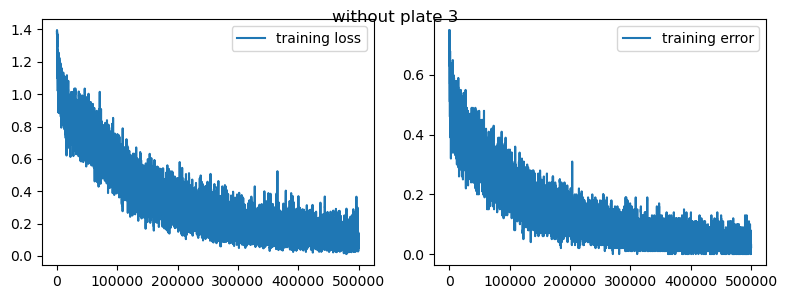

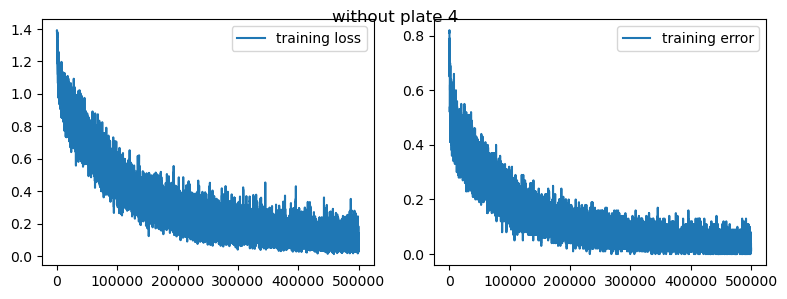

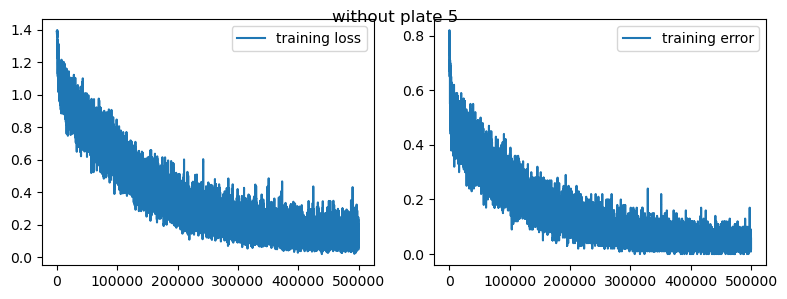

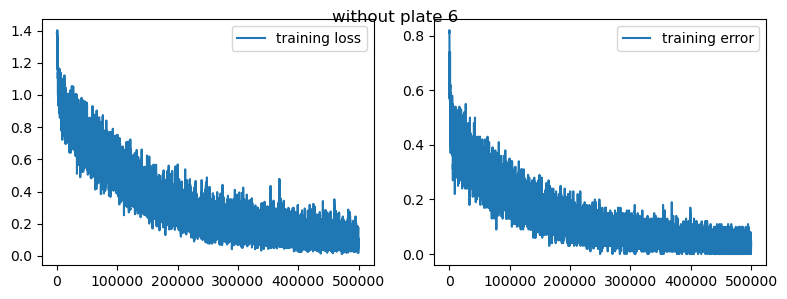

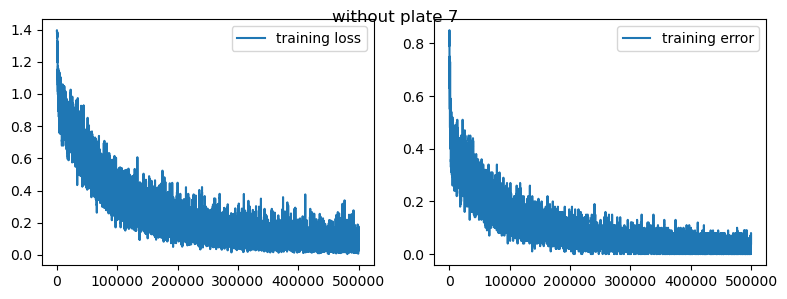

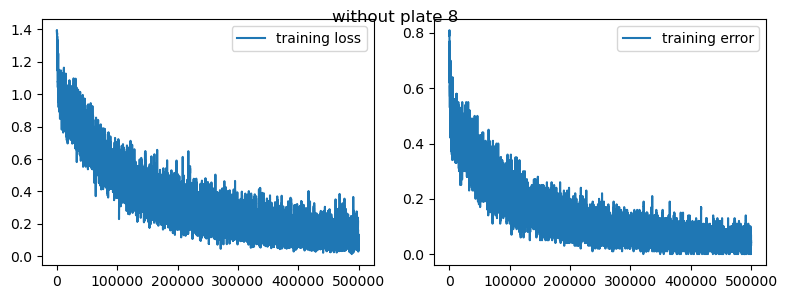

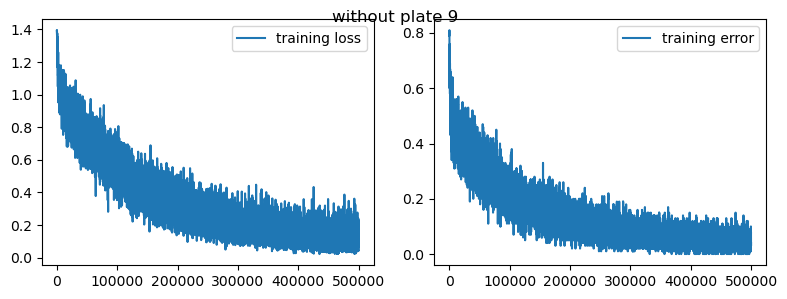

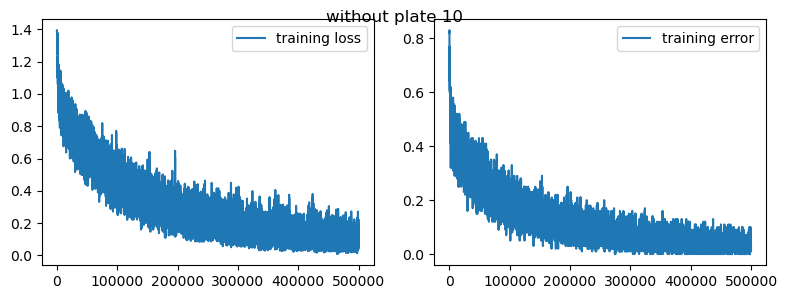

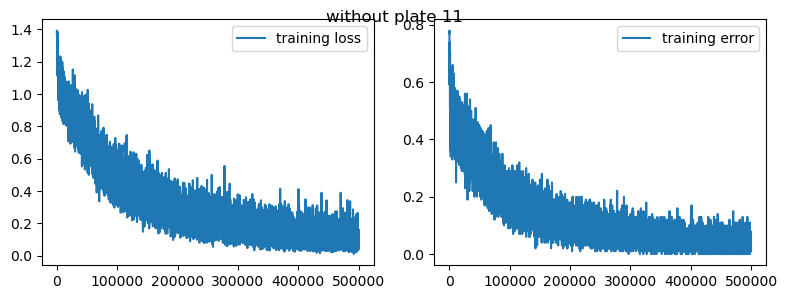

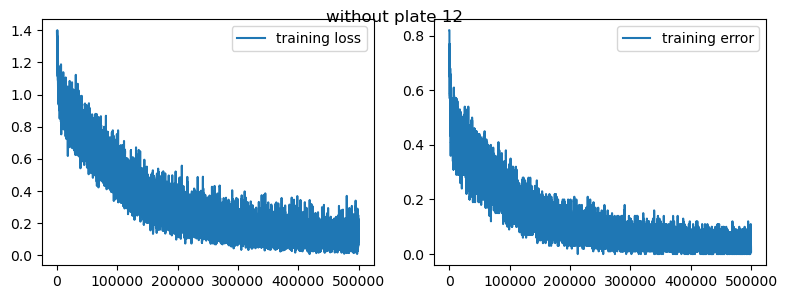

In [44]:
for plate in use_plates:
    name = f'3_12_t01_healthy_groups_without_plate_{plate}_mil'
    train_loader = group_bagloader(use_patients=p01s[~np.isin(p01s, data.info.groupby('plate')['patient'].unique().loc[plate])], use_plates=use_plates[use_plates != plate].copy())
    model = GatedAttentionMulti(classes=len(use_groups), branches=5)
    df = train_model(model, bag_loader=train_loader, num_iter=500_000, lr=0.0001, device=device, fname=name, plot=False, 
                    save_model=True, seed=12341,
                    transform=T.Compose([T.ColorJitter(brightness=0.2, contrast=0.2), T.RandomHorizontalFlip(), T.RandomVerticalFlip()]))

    w = 100
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    ax1.plot(np.convolve(df['train loss'], np.ones(w), 'valid') / w, label='training loss')
    ax2.plot(np.convolve(df['train error'], np.ones(w), 'valid') / w, label='training error')
    ax1.legend()
    ax2.legend()
    fig.tight_layout()
    fig.suptitle(f'without plate {plate}')
    fig.show()

In [45]:
dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_model(f'3_12_t01_healthy_groups_without_plate_{plate}_mil', test_group_bagloader(use_plates=[plate]), branches=5, classes=len(use_groups))
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)
res_without_df

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.36it/s]


,lab,pred,i,pat,group,attention 0,attention 1,attention 2,attention 3,attention 4,raw attention 0,raw attention 1,raw attention 2,raw attention 3,raw attention 4,plate
0,0,0,0,H06,healthy,0.045472,0.058668,0.002653,0.004770,0.001882,1.439693,1.125059,-1.773090,-1.383705,-0.700023,3
1,0,0,0,H06,healthy,0.022605,0.075802,0.002405,0.001268,0.002667,0.740768,1.381292,-1.871296,-2.708481,-0.351512,3
2,0,0,0,H06,healthy,0.010960,0.020922,0.007508,0.009346,0.008222,0.016853,0.093948,-0.732846,-0.711115,0.774554,3
3,0,0,0,H06,healthy,0.017126,0.007603,0.102563,0.019756,0.006448,0.463177,-0.918307,1.881626,0.037345,0.531491,3
4,0,0,0,H06,healthy,0.075443,0.019122,0.041144,0.004494,0.002814,1.945962,0.004005,0.968226,-1.443449,-0.297708,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27245,3,1,34,P21,Chordoma/Chondrosarcoma,0.015758,0.044631,0.006795,0.046518,0.001098,1.221656,3.597661,-2.917345,0.398916,-4.543263,12
27246,3,1,34,P21,Chordoma/Chondrosarcoma,0.009207,0.009933,0.005622,0.001562,0.002003,0.684250,2.095095,-3.106711,-2.994756,-3.941982,12
27247,3,1,34,P21,Chordoma/Chondrosarcoma,0.004923,0.114459,0.010314,0.004067,0.026050,0.058133,4.539452,-2.499948,-2.038051,-1.376659,12
27248,3,1,34,P21,Chordoma/Chondrosarcoma,0.004141,0.000906,0.025489,0.051110,0.060257,-0.114667,-0.300016,-1.595240,0.493046,-0.538059,12


In [46]:
bag_df = res_without_df.groupby(['plate', 'pat', 'i'])[['pred', 'group']].max()  # same value for all (no actual max)
bag_df['pred'] = pd.Categorical(values=bag_df['pred'].map(lambda x: use_groups[x]).replace(short_groups), categories=['H', 'G', 'H&N', 'M', 'C/C'])
bag_df['group'] = pd.Categorical(values=bag_df['group'].replace(short_groups), categories=['H', 'G', 'H&N', 'M', 'C/C'])
bag_df['correct'] = bag_df['pred'] == bag_df['group']
bag_df

pred group  correct
plate pat i                     
3     H06 0     H     H     True
          1     H     H     True
          2     H     H     True
          3     H     H     True
          4     H     H     True
...           ...   ...      ...
12    P21 30    M   C/C    False
          31    M   C/C    False
          32  H&N   C/C    False
          33  H&N   C/C    False
          34  H&N   C/C    False

[545 rows x 3 columns]

In [47]:
bag_df.groupby(['plate', 'group'])['correct'].mean().dropna()

/tmp/ipykernel_1278873/2235028787.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bag_df.groupby(['plate', 'group'])['correct'].mean().dropna()


plate  group
3      H        1.000000
       H&N      0.350000
4      H        0.950000
       H&N      0.533333
5      H        0.250000
       H&N      0.950000
6      H        1.000000
       H&N      0.300000
7      H        1.000000
       M        0.200000
8      H        0.750000
       M        0.550000
9      H        0.850000
       M        0.100000
10     H        1.000000
       C/C      0.066667
11     H        0.850000
       C/C      0.244444
12     H        1.000000
       C/C      0.066667
Name: correct, dtype: float64

In [48]:
bag_df.groupby(['plate'])['correct'].mean()

plate
3     0.675000
4     0.661538
5     0.716667
6     0.500000
7     0.446154
8     0.650000
9     0.475000
10    0.353846
11    0.430769
12    0.600000
Name: correct, dtype: float64

In [49]:
bag_df.groupby(['group'])['correct'].mean()

/tmp/ipykernel_1278873/3077671518.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bag_df.groupby(['group'])['correct'].mean()


group
H      0.865000
G           NaN
H&N    0.541935
M      0.258824
C/C    0.142857
Name: correct, dtype: float64